In [1]:
import pandas as pd

# IPS Colombia — Análisis por Nivel de Complejidad
## Fundamentos de Ciencia de Datos — Universidad de San Buenaventura
### Integrantes: Laura Juliana Salazar — Maria Alejandra Rodriguez


## 1. Descripción del Proyecto
Este proyecto analiza la distribución de las Instituciones Prestadoras de Salud (IPS) 
en Colombia según su nivel de complejidad (1, 2 y 3). El objetivo es identificar 
desigualdades en el acceso a atención médica especializada entre regiones del país.

**Pregunta principal:** ¿Puede predecirse el nivel de complejidad de una IPS según 
su departamento y tipo de institución?


In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print("✅ Librerías importadas correctamente")


Matplotlib is building the font cache; this may take a moment.


✅ Librerías importadas correctamente


## 2. Carga de Datos

In [5]:
# Cargar el dataset
df = pd.read_csv("Listado_de_IPS_en_Colombia_según_su_nivel_de_complejidad_20260508.csv")

# Ver las primeras filas
print("Forma del dataset:", df.shape)
print("Primeras filas:")
df.head()

Forma del dataset: (11466, 27)
Primeras filas:


,depa_nombre,muni_nombre,codigo_habilitacion,nombre_prestador,tido_codigo,nits_nit,razon_social,clpr_codigo,clpr_nombre,ese,...,habilitado,fecha_radicacion,fecha_vencimiento,fecha_cierre,dv,clase_persona,naju_codigo,naju_nombre,numero_sede_principal,fecha_corte_REPS
0,Amazonas,LETICIA,9100100019,E.S.E. HOSPITAL SAN RAFAEL DE LETICIA,NaN,838000096,E.S.E. HOSPITAL SAN RAFAEL DE LETICIA,1,Instituciones - IPS,SI,...,SI,20030409,20220831,NaN,7.0,JURIDICO,4,Pública,1.0,Fecha corte REPS: Jun 16 2022 2:33PM
1,Amazonas,LETICIA,9100100185,FREYA SKIN AND BODY CARE S.A.S TWO,NaN,901438650,FREYA SKIN AND BODY CARE S.A.S TWO,1,Instituciones - IPS,NaN,...,SI,20201221,20241220,NaN,7.0,JURIDICO,1,Privada,1.0,Fecha corte REPS: Jun 16 2022 2:33PM
2,Amazonas,LETICIA,9100100069,FUNDACION CLINICA LETICIA,NaN,900142282,FUNDACION CLINICA LETICIA,1,Instituciones - IPS,NO,...,SI,20070625,20220831,NaN,4.0,JURIDICO,1,Privada,1.0,Fecha corte REPS: Jun 16 2022 2:33PM
3,Amazonas,LETICIA,9100100158,IMPROVE QUALITY REDUCE COST SAVE LIFES AUDITOR...,NaN,900784482,IMPROVE QUALITY REDUCE COST SAVE LIFES AUDITOR...,1,Instituciones - IPS,NaN,...,SI,20161025,20230831,NaN,5.0,JURIDICO,1,Privada,1.0,Fecha corte REPS: Jun 16 2022 2:33PM
4,Amazonas,LETICIA,9100100144,"INSTITUTO PARA LA PREVENCIÓN, EL TRATAMIENTO Y...",NaN,900275974,"INSTITUTO PARA LA PREVENCIÓN, EL TRATAMIENTO Y...",1,Instituciones - IPS,NaN,...,SI,20151026,20220831,NaN,3.0,JURIDICO,1,Privada,1.0,Fecha corte REPS: Jun 16 2022 2:33PM


## 3. Limpieza y Calidad de los Datos

In [6]:
# Ver valores nulos por columna
print("=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())
print()
print("=== FILAS DUPLICADAS ===")
print("Duplicados:", df.duplicated().sum())

=== VALORES NULOS POR COLUMNA ===
depa_nombre                  0
muni_nombre                  0
codigo_habilitacion          0
nombre_prestador             0
tido_codigo              11466
nits_nit                     0
razon_social                 0
clpr_codigo                  0
clpr_nombre                  0
ese                       7965
direccion                    0
telefono                    13
fax                       6739
email                       14
gerente                  11466
nivel                    10464
caracter                 10457
habilitado                   0
fecha_radicacion             0
fecha_vencimiento            0
fecha_cierre             11465
dv                           2
clase_persona                0
naju_codigo                  0
naju_nombre                  0
numero_sede_principal       11
fecha_corte_REPS             0
dtype: int64

=== FILAS DUPLICADAS ===
Duplicados: 0


### 3.1 Limpieza de datos

In [7]:
# Quedarnos solo con IPS que tienen nivel registrado
df_limpio = df[df['nivel'].notna()].copy()

# Quedarnos solo con columnas útiles para el análisis
columnas_utiles = ['depa_nombre', 'muni_nombre', 'nombre_prestador', 
                   'nivel', 'caracter', 'ese']
df_limpio = df_limpio[columnas_utiles]

# Eliminar filas donde caracter sea nulo
df_limpio = df_limpio[df_limpio['caracter'].notna()]

# Resetear índice
df_limpio = df_limpio.reset_index(drop=True)

print("Dataset limpio:")
print("Filas:", len(df_limpio))
print("Columnas:", df_limpio.columns.tolist())
print()
print(df_limpio.isnull().sum())

Dataset limpio:
Filas: 1002
Columnas: ['depa_nombre', 'muni_nombre', 'nombre_prestador', 'nivel', 'caracter', 'ese']

depa_nombre         0
muni_nombre         0
nombre_prestador    0
nivel               0
caracter            0
ese                 0
dtype: int64


### 3.2 Codificación de variables

In [8]:
# Convertir variables de texto a números para el modelo
le_depa = LabelEncoder()
le_caracter = LabelEncoder()
le_ese = LabelEncoder()

df_limpio['depa_cod'] = le_depa.fit_transform(df_limpio['depa_nombre'])
df_limpio['caracter_cod'] = le_caracter.fit_transform(df_limpio['caracter'])
df_limpio['ese_cod'] = le_ese.fit_transform(df_limpio['ese'])
df_limpio['nivel_cod'] = df_limpio['nivel'].astype(int)

print("✅ Variables codificadas correctamente")
print()
print(df_limpio[['depa_nombre','depa_cod','caracter','caracter_cod','ese','ese_cod','nivel','nivel_cod']].head(10))

✅ Variables codificadas correctamente

  depa_nombre  depa_cod       caracter  caracter_cod ese  ese_cod  nivel  \
0    Amazonas         0  DEPARTAMENTAL             0  SI        1    2.0   
1    Amazonas         0       NACIONAL             4  NO        0    1.0   
2    Amazonas         0  DEPARTAMENTAL             0  NO        0    1.0   
3   Antioquia         1      MUNICIPAL             3  SI        1    1.0   
4   Antioquia         1      MUNICIPAL             3  SI        1    1.0   
5   Antioquia         1      MUNICIPAL             3  SI        1    1.0   
6   Antioquia         1      MUNICIPAL             3  SI        1    1.0   
7   Antioquia         1      MUNICIPAL             3  SI        1    1.0   
8   Antioquia         1      MUNICIPAL             3  SI        1    1.0   
9   Antioquia         1      MUNICIPAL             3  SI        1    1.0   

   nivel_cod  
0          2  
1          1  
2          1  
3          1  
4          1  
5          1  
6          1  
7   

## 4. Exploración de Datos

C:\Users\Alejandra_\AppData\Local\Temp\ipykernel_916\661253474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x='nivel_cod', palette='Blues')


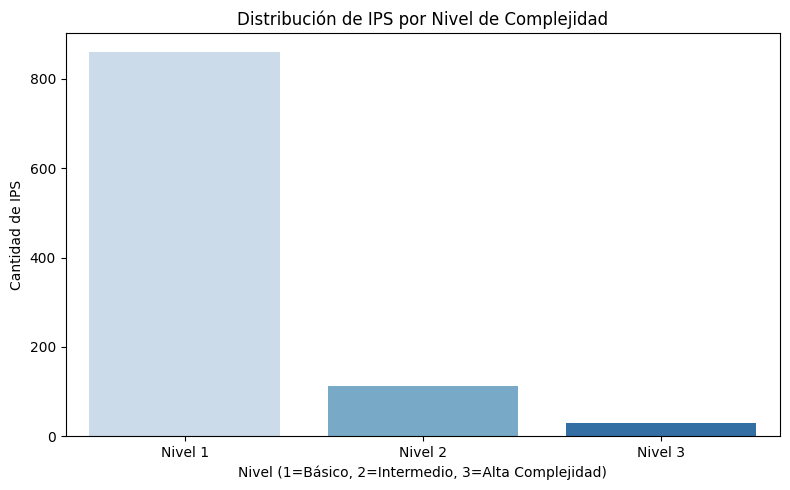

Nivel 1: 860 IPS
Nivel 2: 113 IPS
Nivel 3: 29 IPS


In [9]:
# Distribución de IPS por nivel de complejidad
plt.figure(figsize=(8,5))
sns.countplot(data=df_limpio, x='nivel_cod', palette='Blues')
plt.title('Distribución de IPS por Nivel de Complejidad')
plt.xlabel('Nivel (1=Básico, 2=Intermedio, 3=Alta Complejidad)')
plt.ylabel('Cantidad de IPS')
plt.xticks([0,1,2], ['Nivel 1', 'Nivel 2', 'Nivel 3'])
plt.tight_layout()
plt.show()

print("Nivel 1:", len(df_limpio[df_limpio['nivel_cod']==1]), "IPS")
print("Nivel 2:", len(df_limpio[df_limpio['nivel_cod']==2]), "IPS")
print("Nivel 3:", len(df_limpio[df_limpio['nivel_cod']==3]), "IPS")

C:\Users\Alejandra_\AppData\Local\Temp\ipykernel_916\61444701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_depa.values, y=top_depa.index, palette='Blues_r')


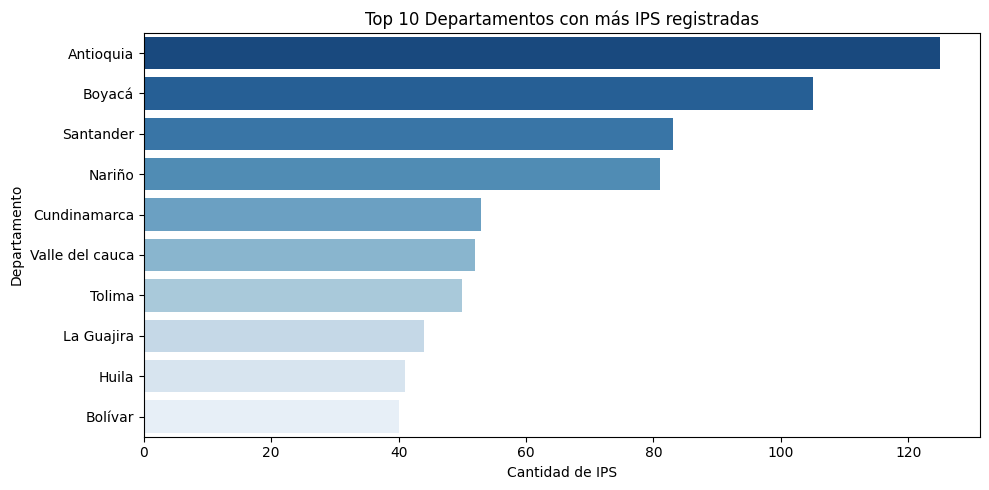

In [10]:
# Top 10 departamentos con más IPS
top_depa = df_limpio['depa_nombre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_depa.values, y=top_depa.index, palette='Blues_r')
plt.title('Top 10 Departamentos con más IPS registradas')
plt.xlabel('Cantidad de IPS')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

C:\Users\Alejandra_\AppData\Local\Temp\ipykernel_916\1058697224.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nivel3.values, y=nivel3.index, palette='Reds_r')


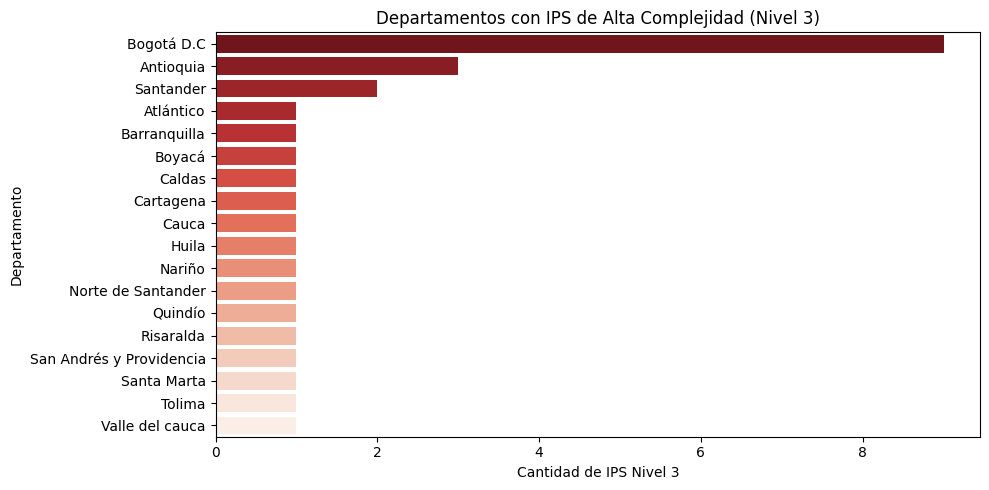

Departamentos SIN IPS de nivel 3:
 - Amazonas
 - Arauca
 - Bolívar
 - Buenaventura
 - Caquetá
 - Casanare
 - Cesar
 - Chocó
 - Cundinamarca
 - Córdoba
 - Guaviare
 - La Guajira
 - Magdalena
 - Meta
 - Putumayo
 - Sucre
 - Vaupés
 - Vichada


In [11]:
# IPS de nivel 3 por departamento (alta complejidad)
nivel3 = df_limpio[df_limpio['nivel_cod']==3]['depa_nombre'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=nivel3.values, y=nivel3.index, palette='Reds_r')
plt.title('Departamentos con IPS de Alta Complejidad (Nivel 3)')
plt.xlabel('Cantidad de IPS Nivel 3')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

print("Departamentos SIN IPS de nivel 3:")
todos = df_limpio['depa_nombre'].unique()
con_nivel3 = nivel3.index.tolist()
sin_nivel3 = [d for d in todos if d not in con_nivel3]
for d in sorted(sin_nivel3):
    print(" -", d)

## 5. Modelado — Clasificación con Random Forest

In [12]:
# Definir variables predictoras y variable objetivo
X = df_limpio[['depa_cod', 'caracter_cod', 'ese_cod']]
y = df_limpio['nivel_cod']

# Dividir en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Evaluar el modelo
y_pred = modelo.predict(X_test)
print("✅ Modelo entrenado correctamente")
print()
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

✅ Modelo entrenado correctamente

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           1       0.94      0.96      0.95       175
           2       0.57      0.60      0.59        20
           3       0.50      0.17      0.25         6

    accuracy                           0.90       201
   macro avg       0.67      0.58      0.60       201
weighted avg       0.89      0.90      0.89       201



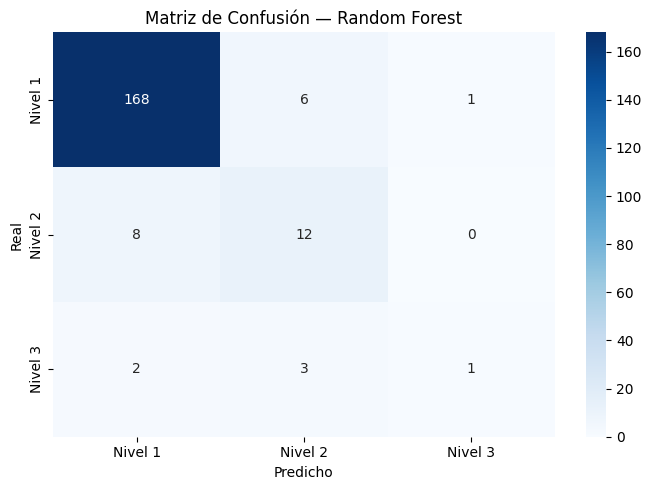

In [13]:
# Matriz de confusión
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nivel 1','Nivel 2','Nivel 3'],
            yticklabels=['Nivel 1','Nivel 2','Nivel 3'])
plt.title('Matriz de Confusión — Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

C:\Users\Alejandra_\AppData\Local\Temp\ipykernel_916\4273306293.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette='Blues_r')


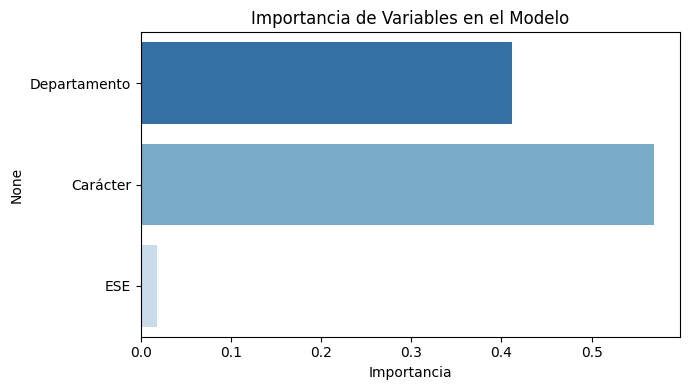

Importancia por variable:
  Departamento: 41.22%
  Carácter: 56.95%
  ESE: 1.83%


In [14]:
# Qué variable influye más en la predicción
importancias = pd.Series(modelo.feature_importances_, 
                         index=['Departamento', 'Carácter', 'ESE'])

plt.figure(figsize=(7,4))
sns.barplot(x=importancias.values, y=importancias.index, palette='Blues_r')
plt.title('Importancia de Variables en el Modelo')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print("Importancia por variable:")
for var, imp in zip(['Departamento','Carácter','ESE'], modelo.feature_importances_):
    print(f"  {var}: {imp:.2%}")

## 6. Conclusiones

- El dataset contiene **1.002 IPS** con nivel de complejidad registrado en Colombia.
- La mayoría son de **Nivel 1 (860 IPS)** — atención básica municipal.
- Solo **29 IPS** en todo el país son de **Nivel 3** (alta complejidad).
- **17 departamentos** no tienen ninguna IPS de alta complejidad, incluyendo Chocó, La Guajira y Vaupés.
- El modelo **Random Forest** alcanzó un **90% de accuracy**.
- La variable más importante para predecir el nivel es el **tipo de institución (56.95%)**, seguido del **departamento (41.22%)**.
- Esto confirma que existe una **desigualdad significativa** en el acceso a salud especializada en Colombia.